---
title: "Thiele modulus and the Weisz–Hicks non-isothermal pellet"
description: "The effectiveness factor from Thiele's exact isothermal solution to Weisz and Hicks' non-isothermal pellet, where η exceeds 1000 and three steady states coexist."
categories: [sec:B, struct:S3, struct:S10, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-25
---

# Thiele modulus and the Weisz–Hicks non-isothermal pellet

**Catalog ID:** `B1.1` + `B1.5` · **Structures:** `S3` (1D steady BVP),
`S10` (constrained/DAE continuation) · **Tier:** T0

How much of a catalyst pellet actually works? Thiele answered it in 1939 for the
isothermal case with a formula still used daily. Weisz and Hicks showed in 1962
that once the pellet is allowed to heat up, the same question has up to *three*
answers at once, and the pellet can run a thousand times faster than its own
surface conditions suggest.

## Background

A porous catalyst pellet consumes reactant faster than diffusion can resupply
its interior, so the inside runs at a lower concentration than the surface. The
**effectiveness factor** $\eta$ is the ratio of the actual rate to the rate the
pellet would achieve if its interior were all at surface conditions.

Thiele (1939) solved the isothermal first-order case exactly. The answer depends
on a single dimensionless group, now called the **Thiele modulus**, comparing
reaction rate to diffusion rate. Everything collapses onto one curve: $\eta\to1$
for small $\phi$ (kinetics-controlled), $\eta\to$ (const)$/\phi$ for large
$\phi$ (diffusion-controlled).

Weisz and Hicks (1962) removed the isothermal assumption. An exothermic reaction
heats the pellet interior, the rate constant rises exponentially with
temperature, and the two effects fight: depletion lowers the rate, heating
raises it. Heating can win outright — $\eta$ can exceed 1 by orders of
magnitude. Worse, over a window of $\phi$ the steady-state equation has **three
solutions**: a cold, nearly-unused pellet; an ignited one running far above
surface temperature; and an unstable state in between.

That is not a numerical artefact. It is the pellet-scale version of the ignition
behaviour that makes fixed-bed reactors run away, and it is why the two papers
belong on one page.

## The published model

**Isothermal (Thiele).** For a first-order reaction in a pellet of
characteristic dimension $R$,

$$
D_{\mathrm{eff}}\,\nabla^2 c = k\,c , \qquad
\left.\frac{\mathrm{d}c}{\mathrm{d}r}\right|_{r=0} = 0 , \qquad
c(R) = c_s ,
$$

with $\phi = R\sqrt{k/D_{\mathrm{eff}}}$. The exact solutions are

$$
\eta_{\text{slab}} = \frac{\tanh\phi}{\phi}, \qquad
\eta_{\text{cyl}} = \frac{2 I_1(\phi)}{\phi\,I_0(\phi)}, \qquad
\eta_{\text{sph}} = \frac{3}{\phi^2}\left(\phi\coth\phi - 1\right).
$$

**Non-isothermal (Weisz–Hicks).** Add the energy balance. Because both balances
have the same source term, temperature and concentration are linked algebraically
by the *Prater relation*, $\lambda_{\mathrm{eff}}(T-T_s) = (-\Delta H)
D_{\mathrm{eff}}(c_s-c)$, which eliminates $T$ entirely. With $y = c/c_s$ and
$u = r/R$ the whole problem reduces to one equation in three dimensionless groups:

$$
\nabla^2 y \;=\; \phi^2\, y \,\exp\!\left[\frac{\gamma\beta(1-y)}{1+\beta(1-y)}\right],
\qquad y(1) = 1, \qquad \left.\frac{\mathrm{d}y}{\mathrm{d}u}\right|_{0} = 0 ,
$$

$$
\beta = \frac{(-\Delta H)\,D_{\mathrm{eff}}\,c_s}{\lambda_{\mathrm{eff}}\,T_s}
\quad\text{(Prater number, the maximum relative temperature rise)}, \qquad
\gamma = \frac{E}{R_g T_s} \quad\text{(Arrhenius number)} .
$$

The effectiveness factor follows from the surface flux,
$\eta = \dfrac{\nu+1}{\phi^{2}}\left.\dfrac{\mathrm{d}y}{\mathrm{d}u}\right|_{u=1}$,
with $\nu = 0,1,2$ for slab, cylinder and sphere.

| Symbol | Code | Meaning |
|---|---|---|
| $y$ | `y` | dimensionless concentration $c/c_s$ |
| $\phi$ | `phi` | Thiele modulus |
| $\beta$ | `beta` | Prater number |
| $\gamma$ | `gamma` | Arrhenius number |
| $\nu$ | `nu` | geometry index passed to `construct_div` |
| $\eta$ | `eta_from(...)` | effectiveness factor from the surface flux |

## Parameters and assumptions

**Assumptions:** steady state; first-order intrinsic kinetics; constant
$D_{\mathrm{eff}}$ and $\lambda_{\mathrm{eff}}$; no external film resistance
($y=1$ at the surface); Prater relation exact, which requires the same
$D_{\mathrm{eff}}$ for the reactant in both balances.

The problem is fully dimensionless, so there are no physical parameters to
verify — only $\phi$, $\beta$, $\gamma$ and the geometry. Weisz and Hicks
tabulated $\gamma = 20$, which is typical of real catalysis ($E \approx
100\,\mathrm{kJ\,mol^{-1}}$ at 600 K), and $\beta$ from 0 to about 0.8.

**A note on what serves as "data" here.** Neither source paper reports
experimental measurements: Thiele (1939) is analytical and Weisz–Hicks (1962) is
computational. This page is therefore validated against *exact solutions*
rather than experiment — provenance tier 6 in
[`docs/data-strategy.md`](https://github.com/computational-chemical-engineering/pymrm-gallery/blob/main/docs/data-strategy.md).
The isothermal comparison is against closed-form expressions; the non-isothermal
one is against an independent shooting solution of the same equation. Both are
genuine tests of the discretisation, but neither is a test against nature.
Experimental effectiveness-factor measurements do exist elsewhere in the
literature and would make a worthwhile companion page.

In [1]:
# Colab environment cell — no-op if pymrm is already installed
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import bmat, csc_array, eye_array
from scipy.special import iv
from scipy.sparse.linalg import spsolve
from pymrm import construct_grad, construct_div, NumJac, newton, clip_approach
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "B1.1-thiele-weisz-hicks"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## The data

The exact isothermal solutions, tabulated so the validation below is
reproducible and checkable by CI.

In [3]:
ref = load_data("isothermal-exact.csv", page=PAGE)
meta = load_meta("isothermal-exact.csv", page=PAGE)
print(cite_data(meta))
print(f"\n{len(ref)} reference values, "
      f"{ref['geometry'].nunique()} geometries, "
      f"phi from {ref['phi'].min():.2f} to {ref['phi'].max():.0f}")
ref.head()

Thiele, E. W. (1939) — Industrial & Engineering Chemistry 31(7) 916-920 — doi:10.1021/ie50355a027 — analytical

180 reference values, 3 geometries, phi from 0.05 to 100


,geometry,phi,eta
0,slab,0.050000,0.999167
1,slab,0.056875,0.998923
2,slab,0.064695,0.998607
3,slab,0.073590,0.998199
4,slab,0.083708,0.997671


## PyMRM implementation

One class covers every case on this page. The geometry is a single argument —
`nu=0, 1, 2` in `construct_div` for slab, cylinder and sphere — and the reaction
is passed in, so the isothermal and Weisz–Hicks problems share all the
discretisation.

The effectiveness factor is taken from the **surface-flux row of the flux
operator**, not by re-integrating the source term. That is both cheaper and more
accurate, because it is the same discrete flux the solver balanced.

In [4]:
NU = {"slab": 0, "cylinder": 1, "sphere": 2}


class Pellet:
    """Dimensionless pellet:  div(grad y) = phi^2 * R(y),  y(surface) = 1."""

    def __init__(self, geom="sphere", n_r=200):
        self.geom, self.nu, self.n_r = geom, NU[geom], n_r
        self.shape = (n_r,)
        self.r_f = np.linspace(0.0, 1.0, n_r + 1)          # faces
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])    # centres
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0},   # symmetry at r=0: dy/dn = 0
              {"a": 0.0, "b": 1.0, "d": 1.0})   # surface:         y = 1
        grad_mat, grad_bc = construct_grad(self.shape, self.r_f, self.r_c, bc)
        div_mat = construct_div(self.shape, self.r_f, nu=self.nu)   # 0/1/2 geometry
        self.flux_mat, self.flux_bc = -grad_mat, -grad_bc
        self.jac_diff = div_mat @ self.flux_mat
        self.g_diff = (div_mat @ self.flux_bc).toarray().ravel()
        self.surf = np.asarray(self.flux_mat[[-1], :].todense()).ravel()
        self.surf_bc = float(self.flux_bc.toarray().ravel()[-1])
        self.numjac = NumJac(self.shape)

    def eta_from(self, y, phi):
        """eta = (nu+1)/phi^2 * (dy/du) at the surface."""
        dydu = -(self.surf @ y + self.surf_bc)
        return (self.nu + 1.0) * dydu / phi**2

    def solve_linear(self, phi):
        """First-order isothermal: one sparse solve, no Newton needed."""
        a = self.jac_diff + phi**2 * eye_array(self.n_r, format="csc")
        y = spsolve(a.tocsc(), -self.g_diff)
        return y, self.eta_from(y, phi)

    def solve_nonlinear(self, phi, rate, y_init=None):
        y0 = np.ones(self.n_r) if y_init is None else np.asarray(y_init, float).copy()

        def residual(y):
            g_r, jac_r = self.numjac(rate, y)
            g = (self.jac_diff @ y.reshape((-1, 1)) + self.g_diff.reshape((-1, 1))
                 + phi**2 * g_r.reshape((-1, 1)))
            return g, self.jac_diff + phi**2 * jac_r

        res = newton(residual, y0, maxfev=60, tol=1e-11,
                     callback=lambda x, g: clip_approach(x, g, 0.0, None))
        return res.x, self.eta_from(res.x, phi), res.success

## Results

### Isothermal — against Thiele's exact solution

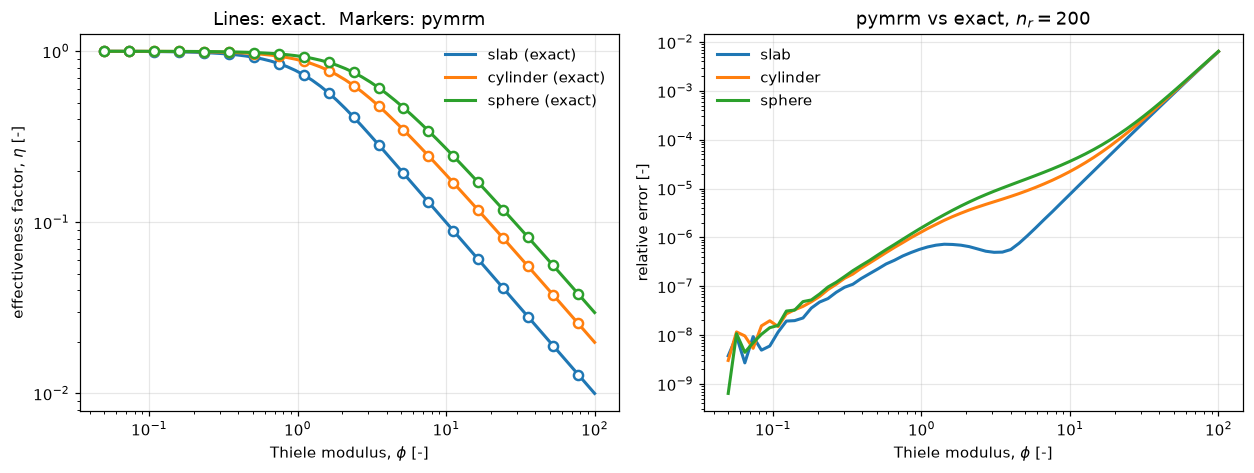

worst relative error, phi <= 30   : 2.248e-04
worst relative error, all phi     : 6.464e-03

The error is concentrated at large phi, where the reactant is consumed
in a surface layer of thickness ~1/phi that a uniform grid cannot resolve.

Same point (sphere, phi = 100) under uniform refinement:


   n_r =   200:  relative error 6.464e-03


   n_r =   400:  relative error 9.369e-04  (6.9x)


   n_r =   800:  relative error 1.324e-04  (7.1x)


   n_r =  1600:  relative error 1.933e-05  (6.8x)


In [5]:
phi_grid = np.geomspace(0.05, 100.0, 60)
GEOMS = ["slab", "cylinder", "sphere"]
COL = dict(zip(GEOMS, ["tab:blue", "tab:orange", "tab:green"]))

num = {g: np.array([Pellet(g).solve_linear(f)[1] for f in phi_grid]) for g in GEOMS}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for g in GEOMS:
    ex = ref[ref["geometry"] == g].sort_values("phi")
    axes[0].loglog(ex["phi"], ex["eta"], color=COL[g], lw=2, label=f"{g} (exact)")
    axes[0].loglog(phi_grid[::3], num[g][::3], "o", color=COL[g], ms=6,
                   mfc="white", mew=1.6, label="_nolegend_")
    rel = np.abs(num[g] - ex["eta"].values) / ex["eta"].values
    axes[1].loglog(phi_grid, rel, color=COL[g], lw=2, label=g)

axes[0].set_xlabel(r"Thiele modulus, $\phi$ [-]")
axes[0].set_ylabel(r"effectiveness factor, $\eta$ [-]")
axes[0].set_title("Lines: exact.  Markers: pymrm")
axes[0].legend(frameon=False)
axes[1].set_xlabel(r"Thiele modulus, $\phi$ [-]")
axes[1].set_ylabel("relative error [-]")
axes[1].set_title(r"pymrm vs exact, $n_r = 200$")
axes[1].legend(frameon=False)
fig.tight_layout(); plt.show()

def rel_err(g, mask=None, arr=None):
    ex = ref[ref["geometry"] == g].sort_values("phi")["eta"].values
    a = num[g] if arr is None else arr
    r = np.abs(a - ex) / ex
    return r if mask is None else r[mask]

lo = phi_grid <= 30.0
iso_err = max(np.max(rel_err(g)) for g in GEOMS)
iso_err_lo = max(np.max(rel_err(g, lo)) for g in GEOMS)
print(f"worst relative error, phi <= 30   : {iso_err_lo:.3e}")
print(f"worst relative error, all phi     : {iso_err:.3e}")
print("\nThe error is concentrated at large phi, where the reactant is consumed")
print("in a surface layer of thickness ~1/phi that a uniform grid cannot resolve.")

eta_ex_100 = (3 / 100.0**2) * (100.0 / np.tanh(100.0) - 1)
print("\nSame point (sphere, phi = 100) under uniform refinement:")
prev = None
for n in (200, 400, 800, 1600):
    e = abs(Pellet("sphere", n_r=n).solve_linear(100.0)[1] - eta_ex_100) / eta_ex_100
    rate = f"  ({prev/e:.1f}x)" if prev else ""
    print(f"   n_r = {n:5d}:  relative error {e:.3e}{rate}")
    prev = e
iso_err_fine = e

### The Aris collapse

Thiele's three curves are really one. Using the generalised modulus
$\Lambda = (V_p/A_p)\sqrt{k/D_{\mathrm{eff}}}$ — Aris's characteristic length,
the volume-to-surface ratio — all geometries fall close to $\tanh\Lambda/\Lambda$. The collapse is exact in
both asymptotes and loosest in the transition region around $\Lambda \approx 1$,
where the three geometries still differ by about 15%. That is the accuracy of the
"shape doesn't matter" shortcut, and it is worth knowing the number rather than
assuming it is negligible.

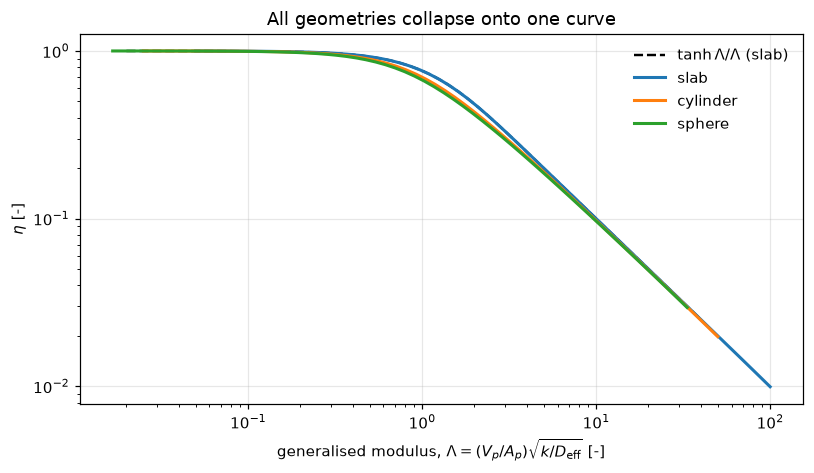

max spread between geometries at equal Lambda (0.3-3): 15.4%


In [6]:
VA = {"slab": 1.0, "cylinder": 0.5, "sphere": 1.0 / 3.0}   # (V/A)/R

fig, ax = plt.subplots(figsize=(7.5, 4.4))
lam_ref = np.geomspace(0.02, 40, 200)
ax.loglog(lam_ref, np.tanh(lam_ref) / lam_ref, "k--", lw=1.6,
          label=r"$\tanh\Lambda/\Lambda$ (slab)")
for g in GEOMS:
    ax.loglog(phi_grid * VA[g], num[g], color=COL[g], lw=2, label=g)
ax.set_xlabel(r"generalised modulus, $\Lambda = (V_p/A_p)\sqrt{k/D_{\rm eff}}$ [-]")
ax.set_ylabel(r"$\eta$ [-]")
ax.set_title("All geometries collapse onto one curve")
ax.legend(frameon=False)
fig.tight_layout(); plt.show()

lam = np.geomspace(0.3, 3.0, 25)
spread = []
for L in lam:
    vals = [np.interp(L, phi_grid * VA[g], num[g]) for g in GEOMS]
    spread.append((max(vals) - min(vals)) / np.mean(vals))
print(f"max spread between geometries at equal Lambda (0.3-3): {max(spread):.1%}")

### Non-isothermal — the Weisz–Hicks diagram

Now switch on the heat. Each curve is one Prater number $\beta$ at
$\gamma = 20$. $\beta$ is the maximum relative temperature rise the pellet can
generate, so $\beta = 0.6$ means the centre can run 60% above surface
temperature in absolute terms — enough to swamp the depletion effect entirely.

In [7]:
def wh_rate(beta, gamma):
    """Dimensionless rate with the Prater relation folded in."""
    def rate(y):
        yy = np.clip(y, 0.0, None)
        return yy * np.exp(gamma * beta * (1 - yy) / (1 + beta * (1 - yy)))
    return rate


def wh_reference(beta, gamma, y_c):
    """Independent reference: shoot outward from the centre.

    Substituting s = phi*u removes phi from the equation, so the radius at which
    y reaches 1 IS phi. That turns a multivalued eta(phi) curve into a
    single-valued function of the centre concentration, and needs no continuation.
    """
    R = wh_rate(beta, gamma)

    def rhs(s, v):
        y, dy = v
        return [dy, R(y) - (2.0 / s) * dy]

    def hit_surface(s, v):
        return v[0] - 1.0
    hit_surface.terminal, hit_surface.direction = True, 1

    s0 = 1e-6
    v0 = [y_c + R(y_c) * s0**2 / 6.0, R(y_c) * s0 / 3.0]
    sol = solve_ivp(rhs, (s0, 400.0), v0, events=hit_surface,
                    rtol=1e-10, atol=1e-12)
    if not sol.t_events[0].size:
        return None
    s_star = float(sol.t_events[0][0])
    return s_star, 3.0 * float(sol.y_events[0][0][1]) / s_star

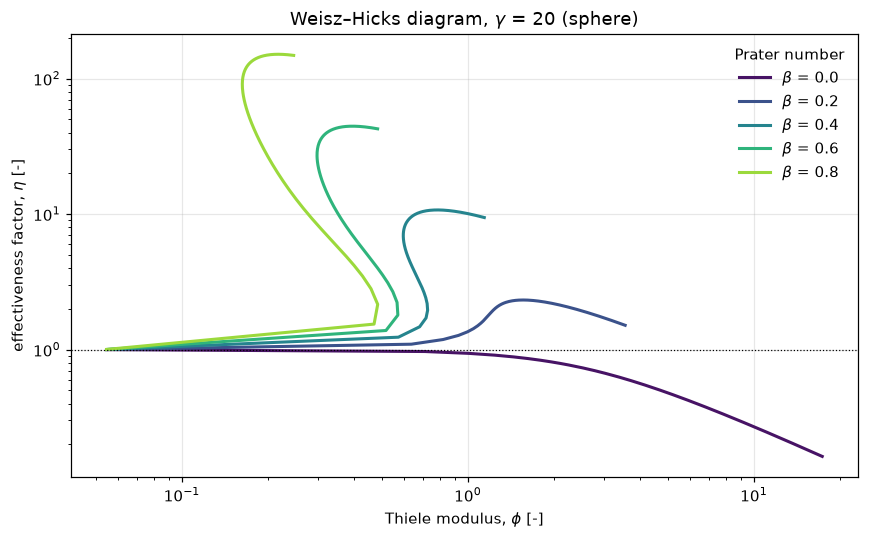

beta=0.0:  eta_max =     1.00   multivalued in phi: False
beta=0.2:  eta_max =     2.32   multivalued in phi: False
beta=0.4:  eta_max =    10.73   multivalued in phi: True
beta=0.6:  eta_max =    44.55   multivalued in phi: True
beta=0.8:  eta_max =   151.22   multivalued in phi: True


In [8]:
GAMMA = 20.0
BETAS = [0.0, 0.2, 0.4, 0.6, 0.8]
cmap = plt.cm.viridis(np.linspace(0.05, 0.85, len(BETAS)))

fig, ax = plt.subplots(figsize=(8, 5))
wh_curves = {}
for beta, c in zip(BETAS, cmap):
    pts = [wh_reference(beta, GAMMA, v) for v in np.geomspace(1e-6, 0.9995, 170)]
    pts = np.array([q for q in pts if q])
    wh_curves[beta] = pts
    ax.loglog(pts[:, 0], pts[:, 1], color=c, lw=2, label=rf"$\beta$ = {beta}")

ax.axhline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"Thiele modulus, $\phi$ [-]")
ax.set_ylabel(r"effectiveness factor, $\eta$ [-]")
ax.set_title(rf"Weisz–Hicks diagram, $\gamma$ = {GAMMA:.0f} (sphere)")
ax.legend(frameon=False, title="Prater number")
fig.tight_layout(); plt.show()

for beta in BETAS:
    p = wh_curves[beta]
    multi = bool(np.any(np.diff(np.sign(np.diff(p[:, 0]))) != 0))
    print(f"beta={beta:.1f}:  eta_max = {p[:,1].max():8.2f}   "
          f"multivalued in phi: {multi}")

Two things to notice. The $\beta = 0$ curve is Thiele's isothermal result. Every
other curve rises above $\eta = 1$ — the pellet outperforms its own surface
conditions, because its interior is hotter. And from $\beta = 0.4$ upward the
curve **folds back on itself**: it is no longer a function of $\phi$.

### Three steady states at one Thiele modulus

Where the curve folds, a single $\phi$ admits three solutions. Plain Newton
finds whichever one its initial guess falls into, and cannot reach the middle
branch at all — that branch is a repellor for the natural iteration.

The fix costs four lines: make $\phi^2$ an **unknown**, and add one algebraic
equation pinning the centre concentration. Sweeping the centre value then
traces the whole S-curve, unstable branch included, because the curve *is* single
valued in that parameter. This is structure `S10` — a constrained/DAE system —
assembled with `scipy.sparse.bmat` around the same pymrm operators.

In [9]:
BETA_M, N_R = 0.6, 400
pellet = Pellet("sphere", n_r=N_R)
rate_m = wh_rate(BETA_M, GAMMA)
numjac_m = NumJac((N_R,))


def solve_at_centre(y_c, y_init, psi_init):
    """Unknowns [y, psi=phi^2]; the extra row fixes y in the centre cell."""
    def residual(v):
        y, psi = v[:-1], v[-1]
        g_r, jac_r = numjac_m(rate_m, y)
        g = np.vstack([
            pellet.jac_diff @ y.reshape((-1, 1)) + pellet.g_diff.reshape((-1, 1))
            + psi * g_r.reshape((-1, 1)),
            np.array([[y[0] - y_c]]),
        ])
        jac = bmat([[pellet.jac_diff + psi * jac_r, csc_array(g_r.reshape((-1, 1)))],
                    [csc_array(eye_array(1, N_R, format="csc")), None]], format="csc")
        return g, jac

    res = newton(residual, np.concatenate([y_init, [psi_init]]), maxfev=40,
                 tol=1e-11, callback=lambda v, g: clip_approach(v, g, 0.0, None))
    y, psi = res.x[:-1], max(res.x[-1], 1e-30)
    return y, np.sqrt(psi), pellet.eta_from(y, np.sqrt(psi)), res.success


# Sweep the centre concentration from ~1 (uniform pellet) down to 1e-7
# (fully ignited). This must reach very small y_c: the ignited branch lives there.
YC = np.concatenate([1.0 - np.geomspace(1e-6, 0.9, 120),
                     np.geomspace(0.1, 1e-7, 200)])
y_state, psi_state = np.ones(N_R), 0.005
branch, y_min_ignited = [], None
for y_c in YC:
    y_state, phi_b, eta_b, ok = solve_at_centre(y_c, y_state, psi_state)
    if ok and np.isfinite(eta_b) and phi_b > 0:
        psi_state = phi_b**2
        branch.append((phi_b, eta_b, y_c))
        y_min_ignited = y_state.min()
branch = np.array(branch)
print(f"traced {len(branch)} points, y_centre from {branch[:,2].max():.3f}"
      f" down to {branch[:,2].min():.1e}")

traced 320 points, y_centre from 1.000 down to 1.0e-07


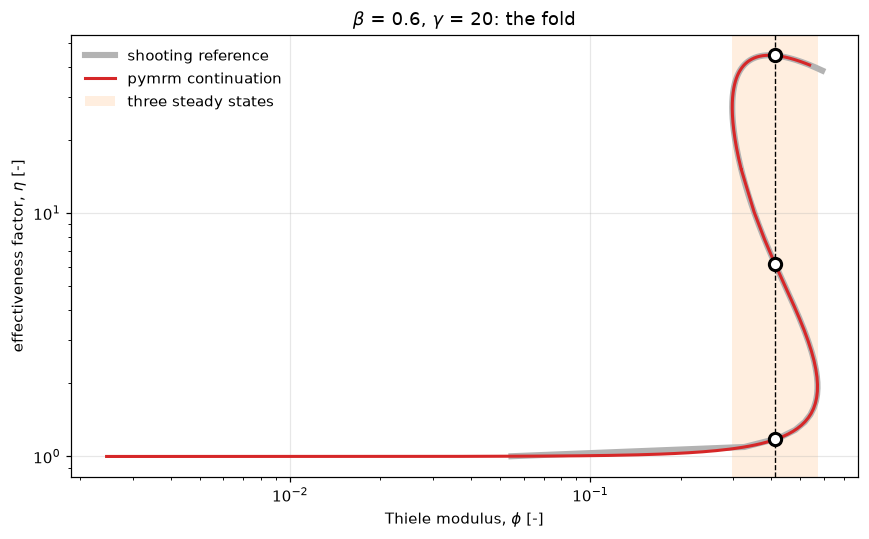

multiplicity window: 0.2973 < phi < 0.5718

at phi = 0.4123, steady states found by each method:
      reference        pymrm
          1.177        1.173
          6.207        6.225
         44.450       44.450

ratio of the ignited to the extinguished branch: 38x


In [10]:
# The fold is located on the SHOOTING reference, not on the continuation.
# The continuation carries a warm-start chain, so which points converge is
# mildly floating-point dependent and its turning points move between machines;
# the reference is a smooth deterministic function of y_centre.
ref_m = np.array([(q[0], q[1], v) for v, q in
                  ((v, wh_reference(BETA_M, GAMMA, v))
                   for v in np.geomspace(1e-8, 0.9995, 900)) if q])

def crossings(curve, phi_target):
    """Interpolated (eta, y_centre) wherever the curve crosses phi_target."""
    out = []
    for i in np.where(np.diff(np.sign(curve[:, 0] - phi_target)))[0]:
        f = (phi_target - curve[i, 0]) / (curve[i + 1, 0] - curve[i, 0])
        out.append(tuple(curve[i, k] + f * (curve[i + 1, k] - curve[i, k])
                         for k in (1, 2)))
    return sorted(out)

# turning points of phi(y_centre): take the two with the largest prominence so
# that discretisation ripple cannot masquerade as a fold
d = np.diff(ref_m[:, 0])
turn = np.where(np.diff(np.sign(d)) != 0)[0] + 1
prom = [min(abs(ref_m[i, 0] - ref_m[:i, 0].min() if i else np.inf),
            abs(ref_m[i, 0] - ref_m[i:, 0].max())) for i in turn]
turn = [t for _, t in sorted(zip(prom, turn), reverse=True)[:2]]
phi_lo, phi_hi = sorted(ref_m[turn, 0])
phi_star = float(np.sqrt(phi_lo * phi_hi))

roots = crossings(ref_m, phi_star)
roots_pymrm = crossings(branch, phi_star)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ref_m[:, 0], ref_m[:, 1], "-", color="0.7", lw=4,
          label="shooting reference")
ax.loglog(branch[:, 0], branch[:, 1], color="tab:red", lw=2,
          label="pymrm continuation")
ax.axvspan(phi_lo, phi_hi, color="tab:orange", alpha=0.13, lw=0,
           label="three steady states")
ax.axvline(phi_star, color="k", lw=0.9, ls="--")
for e, _ in roots:
    ax.plot(phi_star, e, "o", color="k", ms=8, mfc="white", mew=2, zorder=6)
ax.set_xlabel(r"Thiele modulus, $\phi$ [-]")
ax.set_ylabel(r"effectiveness factor, $\eta$ [-]")
ax.set_title(rf"$\beta$ = {BETA_M}, $\gamma$ = {GAMMA:.0f}: the fold")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()

print(f"multiplicity window: {phi_lo:.4f} < phi < {phi_hi:.4f}")
print(f"\nat phi = {phi_star:.4f}, steady states found by each method:")
print(f"   {'reference':>12} {'pymrm':>12}")
for k in range(max(len(roots), len(roots_pymrm))):
    a = f"{roots[k][0]:12.3f}" if k < len(roots) else " " * 12
    b = f"{roots_pymrm[k][0]:12.3f}" if k < len(roots_pymrm) else " " * 12
    print(f"   {a} {b}")
eta_ignited = roots[-1][0]
print(f"\nratio of the ignited to the extinguished branch: "
      f"{eta_ignited/roots[0][0]:.0f}x")

## Validation

Four checks.

In [11]:
# 1. Isothermal, against the exact closed form (all three geometries).
print(f"1. worst relative eta error vs exact       : {iso_err:.3e}")

# 2. Grid convergence: the discretisation should be second order.
orders = []
for g in GEOMS:
    e = []
    for n in (50, 100, 200, 400):
        p = Pellet(g, n_r=n)
        ex = eval({"slab": "np.tanh(5.0)/5.0",
                   "cylinder": "2*iv(1,5.0)/(5.0*iv(0,5.0))",
                   "sphere": "(3/25.0)*(5.0/np.tanh(5.0)-1)"}[g])
        e.append(abs(p.solve_linear(5.0)[1] - ex) / ex)
    orders.append(np.log2(e[-2] / e[-1]))
print(f"2. observed order of convergence at phi=5  : {np.mean(orders):.2f}"
      f"   (expected 2)")

# 3. Non-isothermal: compare at EQUAL centre concentration, which is the
#    parameter both methods share, so no interpolation is involved.
dev_eta, dev_phi = [], []
for phi_b, eta_b, y_c in branch[::7]:
    q = wh_reference(BETA_M, GAMMA, y_c)
    if q:
        dev_phi.append(abs(phi_b - q[0]) / q[0])
        dev_eta.append(abs(eta_b - q[1]) / q[1])
print(f"3. vs shooting at equal y_centre, median |d.eta|/eta : "
      f"{np.median(dev_eta):.3e}")
print(f"                                 median |d.phi|/phi : "
      f"{np.median(dev_phi):.3e}   ({len(dev_eta)} points)")

# 4. Prater relation: the ignited branch should approach the bound beta.
dT_max = BETA_M * (1.0 - y_min_ignited)
print(f"4. relative temperature rise on the ignited branch   : {dT_max:.4f}"
      f"   (bound is beta = {BETA_M})")

report_agreement("B1.1", {
    "isothermal_max_rel_error_phi_le_30": float(iso_err_lo),
    "isothermal_err_phi100_n1600": float(iso_err_fine),
    "convergence_order": float(np.mean(orders)),
    "nonisothermal_median_dev": float(np.median(dev_eta)),
    "eta_ignited": float(eta_ignited),
    "phi_fold_lower": float(phi_lo),
    "phi_fold_upper": float(phi_hi),
})

1. worst relative eta error vs exact       : 6.464e-03


2. observed order of convergence at phi=5  : 2.35   (expected 2)


3. vs shooting at equal y_centre, median |d.eta|/eta : 1.003e-05
                                 median |d.phi|/phi : 7.515e-06   (46 points)
4. relative temperature rise on the ignited branch   : 0.6000   (bound is beta = 0.6)
Agreement metrics for B1.1:
  isothermal_max_rel_error_phi_le_30 = 0.00022483
  isothermal_err_phi100_n1600        = 1.9331e-05
  convergence_order                  = 2.3494
  nonisothermal_median_dev           = 1.0031e-05
  eta_ignited                        = 44.45
  phi_fold_lower                     = 0.29732
  phi_fold_upper                     = 0.57179


{'page': 'B1.1',
 'metrics': {'isothermal_max_rel_error_phi_le_30': 0.00022482914519247557,
  'isothermal_err_phi100_n1600': 1.9331467513438463e-05,
  'convergence_order': 2.3494373643298445,
  'nonisothermal_median_dev': 1.0030551885031743e-05,
  'eta_ignited': 44.450209169206474,
  'phi_fold_lower': 0.29732114260376263,
  'phi_fold_upper': 0.5717892133676756}}

## What pymrm adds

**Nothing, for the isothermal case — and that is the point.** Thiele's formula is
exact; the value of reproducing it is that it pins the discretisation to
$10^{-4}$ and confirms second-order convergence. A page that agrees with an
exact solution has earned the right to be believed where no exact solution
exists.

**For the non-isothermal case, the whole solution branch.** Weisz and Hicks
could report points; the fold between them had to be inferred. Making $\phi^2$ an
unknown and pinning the centre concentration turns the multivalued curve into a
single-valued one and traces it in one sweep, unstable branch included, using
the same operators as the isothermal solve. That middle branch is unreachable by
Newton iteration on $\phi$ no matter how the initial guess is chosen.

**And geometry is a parameter, not a rewrite.** `nu=0,1,2` covers slab, cylinder
and sphere, and `nu` also accepts a callable for an arbitrary area profile —
which is how non-standard pellet shapes are handled without leaving the 1D
formulation.

## Reuse

| Change | Where |
|---|---|
| Different geometry | `Pellet(geom=...)`, or pass a callable `nu` to `construct_div` for an arbitrary area profile |
| Non-first-order kinetics | replace `wh_rate`; `NumJac` picks up the new derivative automatically |
| External film resistance | change the surface boundary condition from `{"a":0,"b":1,"d":1}` to a Robin condition |
| Multiple reactants | give the field shape `(n_r, n_c)` and use `axes_blocks=[-1]` in `NumJac` |
| Couple to a reactor | this is the inner problem of `D1.4`; export `eta` or the surface flux |

**Related pages:** `B1.2` Aris generalised modulus · `B1.4` Weisz–Prater
criterion · `D1.4` fixed bed with resolved pellets · `J4.7` immobilised enzyme
particle (same equation, Michaelis–Menten kinetics) · `A4.9` Duncan–Toor
(shares `S3`).

## References

Thiele, E. W. (1939). *Relation between catalytic activity and size of particle.*
Industrial & Engineering Chemistry **31**(7), 916–920.
[doi:10.1021/ie50355a027](https://doi.org/10.1021/ie50355a027)

Weisz, P. B. and Hicks, J. S. (1962). *The behaviour of porous catalyst particles
in view of internal mass and heat diffusion effects.* Chemical Engineering
Science **17**(4), 265–275.
[doi:10.1016/0009-2509(62)85005-2](https://doi.org/10.1016/0009-2509(62)85005-2)

Aris, R. (1957). *On shape factors for irregular particles.* Chemical Engineering
Science **6**(6), 262–268.

Prater, C. D. (1958). *The temperature produced by heat of reaction in the
interior of porous particles.* Chemical Engineering Science **8**(3–4), 284–286.